# MBO Foil Profile Comparison: AIC-144 vs CCB

This notebook compares MBO foil profiles from AIC-144 and CCB facilities.
Profiles are loaded from pre-processed npz files and rescaled to 5 Gy at X = 5 mm.

In [15]:
# Imports
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Add src to path
project_root = Path.cwd().parents[2]
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

## Configuration

In [16]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Data paths for profile files
AIC144_PROFILE_PATH = Path(r"C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_aic144\2025-10-09\profile_foils_1_2.npz")
CCB_PROFILE_PATH = Path(r"C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_ccb\2025-12-19\profile_foils_3_2.npz")

# Reference dose for normalization
REFERENCE_DOSE_GY = 5.0         # Gy
REFERENCE_X_MM = 5.0            # mm position for normalization

print(f'AIC-144 profile exists: {AIC144_PROFILE_PATH.exists()}')
print(f'CCB profile exists: {CCB_PROFILE_PATH.exists()}')

AIC-144 profile exists: True
CCB profile exists: True


## Load Profile Data

In [17]:
# Load profile data from npz files
aic144_data = np.load(AIC144_PROFILE_PATH)
ccb_data = np.load(CCB_PROFILE_PATH)

# Extract arrays
x_mm_aic144 = aic144_data['x_mm']
profile_aic144 = aic144_data['profile_opt_smooth']

x_mm_ccb = ccb_data['x_mm']
profile_ccb = ccb_data['profile_opt_smooth']

# Display loaded data info
print('AIC-144 profile:')
print(f'  X range: [{x_mm_aic144.min():.2f}, {x_mm_aic144.max():.2f}] mm')
print(f'  Intensity range: [{profile_aic144.min():.2f}, {profile_aic144.max():.2f}]')
print(f'  Points: {len(x_mm_aic144)}')

print('\nCCB profile:')
print(f'  X range: [{x_mm_ccb.min():.2f}, {x_mm_ccb.max():.2f}] mm')
print(f'  Intensity range: [{profile_ccb.min():.2f}, {profile_ccb.max():.2f}]')
print(f'  Points: {len(x_mm_ccb)}')

AIC-144 profile:
  X range: [0.00, 37.30] mm
  Intensity range: [6.88, 2480.36]
  Points: 505

CCB profile:
  X range: [0.00, 41.00] mm
  Intensity range: [5.29, 2039.53]
  Points: 555


## Normalize Profiles to 5 Gy at X = 5 mm

Rescale dose profiles so that the dose at X = 5 mm equals 5 Gy.

In [18]:
def get_value_at_x(x_arr, profile, target_x):
    """Get interpolated profile value at target_x position."""
    idx = np.abs(x_arr - target_x).argmin()
    
    # Linear interpolation for more accurate value
    if idx > 0 and idx < len(x_arr) - 1:
        if x_arr[idx] > target_x:
            x0, x1 = x_arr[idx-1], x_arr[idx]
            y0, y1 = profile[idx-1], profile[idx]
        else:
            x0, x1 = x_arr[idx], x_arr[idx+1]
            y0, y1 = profile[idx], profile[idx+1]
        
        frac = (target_x - x0) / (x1 - x0)
        return y0 + frac * (y1 - y0)
    
    return profile[idx]

# Get intensity values at X = 5 mm
intensity_at_5mm_aic144 = get_value_at_x(x_mm_aic144, profile_aic144, REFERENCE_X_MM)
intensity_at_5mm_ccb = get_value_at_x(x_mm_ccb, profile_ccb, REFERENCE_X_MM)

# Calculate scale factors to normalize to 5 Gy at X = 5 mm
scale_aic144 = REFERENCE_DOSE_GY / intensity_at_5mm_aic144
scale_ccb = REFERENCE_DOSE_GY / intensity_at_5mm_ccb

print(f'AIC-144: intensity at X={REFERENCE_X_MM}mm = {intensity_at_5mm_aic144:.2f}, scale factor = {scale_aic144:.6f}')
print(f'CCB: intensity at X={REFERENCE_X_MM}mm = {intensity_at_5mm_ccb:.2f}, scale factor = {scale_ccb:.6f}')

# Apply scaling to convert intensity to dose [Gy]
dose_aic144 = profile_aic144 * scale_aic144
dose_ccb = profile_ccb * scale_ccb

print(f'\nAfter normalization:')
print(f'AIC-144 dose range: [{dose_aic144.min():.2f}, {dose_aic144.max():.2f}] Gy')
print(f'CCB dose range: [{dose_ccb.min():.2f}, {dose_ccb.max():.2f}] Gy')

AIC-144: intensity at X=5.0mm = 662.67, scale factor = 0.007545
CCB: intensity at X=5.0mm = 735.50, scale factor = 0.006798

After normalization:
AIC-144 dose range: [0.05, 18.71] Gy
CCB dose range: [0.04, 13.86] Gy


## Profile Comparison with Metrics

Calculate and display FWHM, range (90% position), and distal falloff (80%-20% and 90%-10%).

In [19]:
# Helper functions for profile analysis

def find_fwhm_boundaries(profile, x_mm):
    """Find left and right FWHM boundaries."""
    max_val = np.max(profile)
    max_idx = np.argmax(profile)
    half_max = max_val / 2
    
    left_pos = None
    right_pos = None
    
    # Left side (before max)
    for i in range(max_idx - 1, -1, -1):
        if profile[i] < half_max <= profile[i + 1]:
            frac = (half_max - profile[i]) / (profile[i + 1] - profile[i])
            left_pos = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            break
    
    # Right side (after max)
    for i in range(max_idx, len(profile) - 1):
        if profile[i] >= half_max > profile[i + 1]:
            frac = (half_max - profile[i]) / (profile[i + 1] - profile[i])
            right_pos = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            break
    
    return left_pos, right_pos, half_max


def find_distal_percent_position(profile, x_mm, target_percent):
    """Find distal position where dose drops to target_percent of max."""
    max_val = np.max(profile)
    max_idx = np.argmax(profile)
    target_val = max_val * target_percent / 100.0
    
    # Search on distal (right) side after max
    for i in range(max_idx, len(profile) - 1):
        if profile[i] >= target_val > profile[i + 1]:
            # Linear interpolation
            frac = (target_val - profile[i]) / (profile[i + 1] - profile[i])
            x_pos = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            return x_pos, target_val
    return None, None


def calculate_profile_metrics(profile, x_mm):
    """Calculate FWHM and distal falloff distances for a profile."""
    max_val = np.max(profile)
    max_idx = np.argmax(profile)
    
    # Normalize profile for percentage calculations
    profile_norm = profile / max_val * 100
    
    # FWHM: find positions where profile crosses 50%
    half_max = 50.0
    left_idx = None
    right_idx = None
    
    # Left side (before max)
    for i in range(max_idx - 1, -1, -1):
        if profile_norm[i] < half_max <= profile_norm[i + 1]:
            frac = (half_max - profile_norm[i]) / (profile_norm[i + 1] - profile_norm[i])
            left_idx = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            break
    
    # Right side (after max) - distal
    for i in range(max_idx, len(profile_norm) - 1):
        if profile_norm[i] >= half_max > profile_norm[i + 1]:
            frac = (half_max - profile_norm[i]) / (profile_norm[i + 1] - profile_norm[i])
            right_idx = x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
            break
    
    fwhm = right_idx - left_idx if (left_idx is not None and right_idx is not None) else np.nan
    
    # Distal falloff: find positions for different percentages
    def find_distal_position(target_percent):
        for i in range(max_idx, len(profile_norm) - 1):
            if profile_norm[i] >= target_percent > profile_norm[i + 1]:
                frac = (target_percent - profile_norm[i]) / (profile_norm[i + 1] - profile_norm[i])
                return x_mm[i] + frac * (x_mm[i + 1] - x_mm[i])
        return np.nan
    
    pos_90 = find_distal_position(90.0)
    pos_80 = find_distal_position(80.0)
    pos_20 = find_distal_position(20.0)
    pos_10 = find_distal_position(10.0)
    
    dist_90_10 = pos_10 - pos_90 if not (np.isnan(pos_90) or np.isnan(pos_10)) else np.nan
    dist_80_20 = pos_20 - pos_80 if not (np.isnan(pos_80) or np.isnan(pos_20)) else np.nan
    
    return {
        'fwhm': fwhm,
        'pos_90': pos_90,
        'pos_80': pos_80,
        'pos_20': pos_20,
        'pos_10': pos_10,
        'dist_90_10': dist_90_10,
        'dist_80_20': dist_80_20
    }

In [20]:
# Calculate metrics for both profiles
left_aic144, right_aic144, hm_aic144 = find_fwhm_boundaries(dose_aic144, x_mm_aic144)
left_ccb, right_ccb, hm_ccb = find_fwhm_boundaries(dose_ccb, x_mm_ccb)

fwhm_aic144 = right_aic144 - left_aic144 if (left_aic144 is not None and right_aic144 is not None) else np.nan
fwhm_ccb = right_ccb - left_ccb if (left_ccb is not None and right_ccb is not None) else np.nan

# Find 90% and 80% positions (range indicators)
x_90_aic144, dose_90_aic144 = find_distal_percent_position(dose_aic144, x_mm_aic144, 90)
x_90_ccb, dose_90_ccb = find_distal_percent_position(dose_ccb, x_mm_ccb, 90)

x_80_aic144, dose_80_aic144 = find_distal_percent_position(dose_aic144, x_mm_aic144, 80)
x_80_ccb, dose_80_ccb = find_distal_percent_position(dose_ccb, x_mm_ccb, 80)

x_20_aic144, dose_20_aic144 = find_distal_percent_position(dose_aic144, x_mm_aic144, 20)
x_20_ccb, dose_20_ccb = find_distal_percent_position(dose_ccb, x_mm_ccb, 20)

x_10_aic144, dose_10_aic144 = find_distal_percent_position(dose_aic144, x_mm_aic144, 10)
x_10_ccb, dose_10_ccb = find_distal_percent_position(dose_ccb, x_mm_ccb, 10)

# Calculate distal falloff distances
dist_80_20_aic144 = x_20_aic144 - x_80_aic144 if (x_20_aic144 is not None and x_80_aic144 is not None) else np.nan
dist_80_20_ccb = x_20_ccb - x_80_ccb if (x_20_ccb is not None and x_80_ccb is not None) else np.nan

dist_90_10_aic144 = x_10_aic144 - x_90_aic144 if (x_10_aic144 is not None and x_90_aic144 is not None) else np.nan
dist_90_10_ccb = x_10_ccb - x_90_ccb if (x_10_ccb is not None and x_90_ccb is not None) else np.nan

print('Profile metrics:')
print(f'  AIC-144 FWHM: {fwhm_aic144:.2f} mm')
print(f'  CCB FWHM: {fwhm_ccb:.2f} mm')
print(f'  AIC-144 90% position (range): {x_90_aic144:.2f} mm')
print(f'  CCB 90% position (range): {x_90_ccb:.2f} mm')
print(f'  AIC-144 distal falloff (80%-20%): {dist_80_20_aic144:.2f} mm')
print(f'  CCB distal falloff (80%-20%): {dist_80_20_ccb:.2f} mm')

Profile metrics:
  AIC-144 FWHM: 8.45 mm
  CCB FWHM: 13.34 mm
  AIC-144 90% position (range): 29.38 mm
  CCB 90% position (range): 35.25 mm
  AIC-144 distal falloff (80%-20%): 1.42 mm
  CCB distal falloff (80%-20%): 1.78 mm


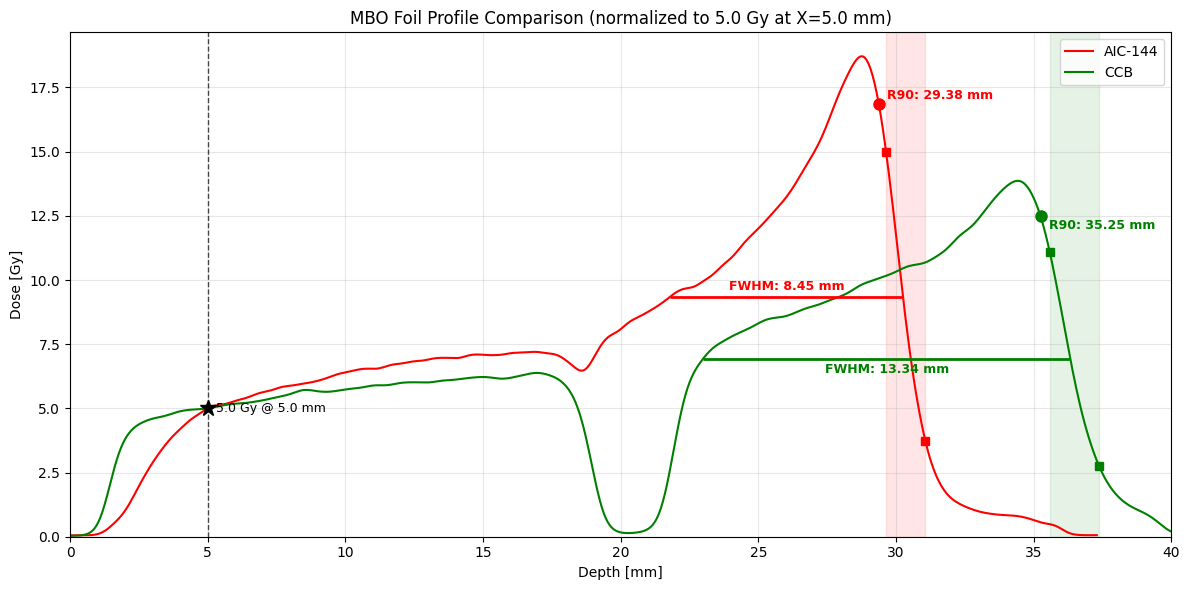

In [21]:
# Main comparison plot with FWHM, range, and distal falloff
fig, ax = plt.subplots(figsize=(12, 6))

# Plot profiles
ax.plot(x_mm_aic144, dose_aic144, color='red', label='AIC-144', linewidth=1.5)
ax.plot(x_mm_ccb, dose_ccb, color='green', label='CCB', linewidth=1.5)

# Add FWHM horizontal segments
# AIC-144 FWHM (red)
if left_aic144 is not None and right_aic144 is not None:
    ax.hlines(y=hm_aic144, xmin=left_aic144, xmax=right_aic144, color='red', linewidth=2, linestyle='-')
    ax.text((left_aic144 + right_aic144) / 2, hm_aic144 + 0.15, f'FWHM: {fwhm_aic144:.2f} mm', 
            ha='center', va='bottom', color='red', fontsize=9, fontweight='bold')

# CCB FWHM (green)
if left_ccb is not None and right_ccb is not None:
    ax.hlines(y=hm_ccb, xmin=left_ccb, xmax=right_ccb, color='green', linewidth=2, linestyle='-')
    ax.text((left_ccb + right_ccb) / 2, hm_ccb - 0.15, f'FWHM: {fwhm_ccb:.2f} mm', 
            ha='center', va='top', color='green', fontsize=9, fontweight='bold')

# Add 90% markers (Range)
if x_90_aic144 is not None:
    ax.plot(x_90_aic144, dose_90_aic144, 'o', color='red', markersize=8)
    ax.text(x_90_aic144 + 0.3, dose_90_aic144 + 0.1, f'R90: {x_90_aic144:.2f} mm', 
            ha='left', va='bottom', color='red', fontsize=9, fontweight='bold')

if x_90_ccb is not None:
    ax.plot(x_90_ccb, dose_90_ccb, 'o', color='green', markersize=8)
    ax.text(x_90_ccb + 0.3, dose_90_ccb - 0.1, f'R90: {x_90_ccb:.2f} mm', 
            ha='left', va='top', color='green', fontsize=9, fontweight='bold')

# Add distal falloff region markers (80%-20%)
# AIC-144 distal falloff
if x_80_aic144 is not None and x_20_aic144 is not None:
    ax.axvspan(x_80_aic144, x_20_aic144, alpha=0.1, color='red')
    ax.plot(x_80_aic144, dose_80_aic144, 's', color='red', markersize=6)
    ax.plot(x_20_aic144, dose_20_aic144, 's', color='red', markersize=6)

# CCB distal falloff
if x_80_ccb is not None and x_20_ccb is not None:
    ax.axvspan(x_80_ccb, x_20_ccb, alpha=0.1, color='green')
    ax.plot(x_80_ccb, dose_80_ccb, 's', color='green', markersize=6)
    ax.plot(x_20_ccb, dose_20_ccb, 's', color='green', markersize=6)

# Add reference point at X = 5 mm
ax.axvline(x=REFERENCE_X_MM, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.plot(REFERENCE_X_MM, REFERENCE_DOSE_GY, 'k*', markersize=12)
ax.text(REFERENCE_X_MM + 0.3, REFERENCE_DOSE_GY, f'{REFERENCE_DOSE_GY} Gy @ {REFERENCE_X_MM} mm', 
        ha='left', va='center', fontsize=9)

ax.set_xlabel('Depth [mm]')
ax.set_ylabel('Dose [Gy]')
ax.set_title(f'MBO Foil Profile Comparison (normalized to {REFERENCE_DOSE_GY} Gy at X={REFERENCE_X_MM} mm)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, None)
ax.set_xlim(0, 40)

plt.tight_layout()
plt.show()

## Profile Metrics Summary

In [22]:
# Calculate full metrics using helper function
metrics_aic144 = calculate_profile_metrics(dose_aic144, x_mm_aic144)
metrics_ccb = calculate_profile_metrics(dose_ccb, x_mm_ccb)

# Display summary table
print('=' * 70)
print('MBO FOIL PROFILE METRICS COMPARISON')
print('=' * 70)
print(f'{"Metric":<25} {"AIC-144":>15} {"CCB":>15} {"Difference":>12}')
print('-' * 70)
print(f'{"FWHM [mm]":<25} {metrics_aic144["fwhm"]:>15.2f} {metrics_ccb["fwhm"]:>15.2f} {metrics_aic144["fwhm"] - metrics_ccb["fwhm"]:>12.2f}')
print(f'{"Range (90%) [mm]":<25} {metrics_aic144["pos_90"]:>15.2f} {metrics_ccb["pos_90"]:>15.2f} {metrics_aic144["pos_90"] - metrics_ccb["pos_90"]:>12.2f}')
print(f'{"Distal 90%-10% [mm]":<25} {metrics_aic144["dist_90_10"]:>15.2f} {metrics_ccb["dist_90_10"]:>15.2f} {metrics_aic144["dist_90_10"] - metrics_ccb["dist_90_10"]:>12.2f}')
print(f'{"Distal 80%-20% [mm]":<25} {metrics_aic144["dist_80_20"]:>15.2f} {metrics_ccb["dist_80_20"]:>15.2f} {metrics_aic144["dist_80_20"] - metrics_ccb["dist_80_20"]:>12.2f}')
print('-' * 70)

print('\n--- Detailed Distal Positions ---')
print(f'{"Dataset":<12} {"90% [mm]":>10} {"80% [mm]":>10} {"20% [mm]":>10} {"10% [mm]":>10}')
print('-' * 54)
print(f'{"AIC-144":<12} {metrics_aic144["pos_90"]:>10.2f} {metrics_aic144["pos_80"]:>10.2f} {metrics_aic144["pos_20"]:>10.2f} {metrics_aic144["pos_10"]:>10.2f}')
print(f'{"CCB":<12} {metrics_ccb["pos_90"]:>10.2f} {metrics_ccb["pos_80"]:>10.2f} {metrics_ccb["pos_20"]:>10.2f} {metrics_ccb["pos_10"]:>10.2f}')

MBO FOIL PROFILE METRICS COMPARISON
Metric                            AIC-144             CCB   Difference
----------------------------------------------------------------------
FWHM [mm]                            8.45           13.34        -4.89
Range (90%) [mm]                    29.38           35.25        -5.87
Distal 90%-10% [mm]                  2.33            3.00        -0.67
Distal 80%-20% [mm]                  1.42            1.78        -0.36
----------------------------------------------------------------------

--- Detailed Distal Positions ---
Dataset        90% [mm]   80% [mm]   20% [mm]   10% [mm]
------------------------------------------------------
AIC-144           29.38      29.64      31.07      31.71
CCB               35.25      35.59      37.37      38.25


## Distal Falloff Detail

Zoomed view of the distal falloff region showing 90%, 80%, 20%, and 10% dose levels.

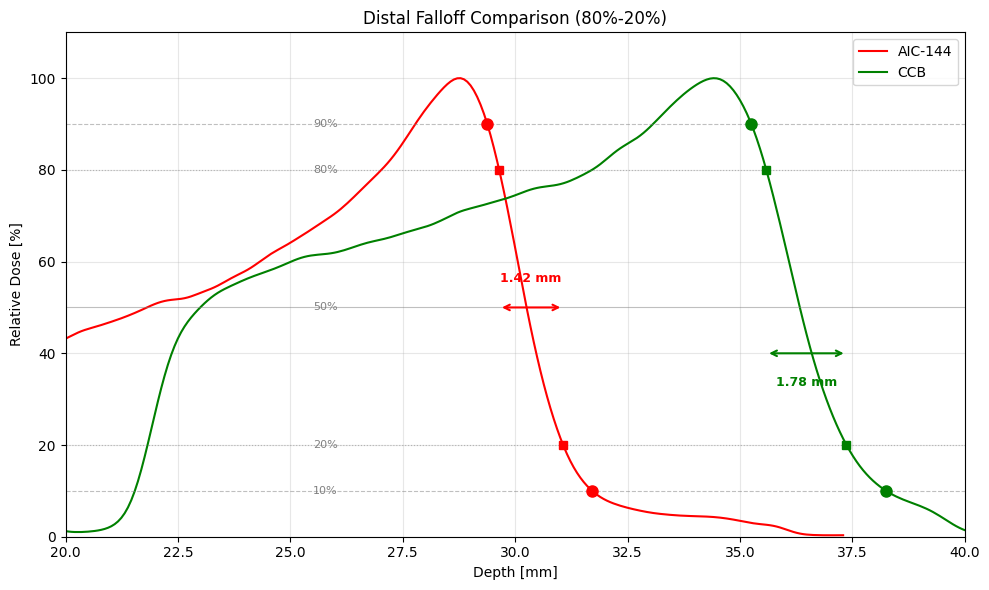

In [23]:
# Detailed distal falloff comparison
fig, ax = plt.subplots(figsize=(10, 6))

# Plot profiles (normalized to percentage of max)
max_aic144 = np.max(dose_aic144)
max_ccb = np.max(dose_ccb)

dose_aic144_norm = dose_aic144 / max_aic144 * 100
dose_ccb_norm = dose_ccb / max_ccb * 100

ax.plot(x_mm_aic144, dose_aic144_norm, color='red', label='AIC-144', linewidth=1.5)
ax.plot(x_mm_ccb, dose_ccb_norm, color='green', label='CCB', linewidth=1.5)

# Add horizontal lines at key percentage levels
for level, style in [(90, '--'), (80, ':'), (50, '-'), (20, ':'), (10, '--')]:
    ax.axhline(y=level, color='gray', linestyle=style, linewidth=0.8, alpha=0.5)
    ax.text(25.5, level, f'{level}%', va='center', fontsize=8, color='gray')

# Add markers at key positions
# AIC-144 markers
if metrics_aic144['pos_90'] is not None and not np.isnan(metrics_aic144['pos_90']):
    ax.plot(metrics_aic144['pos_90'], 90, 'ro', markersize=8)
    ax.plot(metrics_aic144['pos_80'], 80, 'rs', markersize=6)
    ax.plot(metrics_aic144['pos_20'], 20, 'rs', markersize=6)
    ax.plot(metrics_aic144['pos_10'], 10, 'ro', markersize=8)
    
    # Annotate distal falloff distance
    mid_x_aic = (metrics_aic144['pos_80'] + metrics_aic144['pos_20']) / 2
    ax.annotate('', xy=(metrics_aic144['pos_20'], 50), xytext=(metrics_aic144['pos_80'], 50),
                arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
    ax.text(mid_x_aic, 55, f'{metrics_aic144["dist_80_20"]:.2f} mm', 
            ha='center', va='bottom', color='red', fontsize=9, fontweight='bold')

# CCB markers
if metrics_ccb['pos_90'] is not None and not np.isnan(metrics_ccb['pos_90']):
    ax.plot(metrics_ccb['pos_90'], 90, 'go', markersize=8)
    ax.plot(metrics_ccb['pos_80'], 80, 'gs', markersize=6)
    ax.plot(metrics_ccb['pos_20'], 20, 'gs', markersize=6)
    ax.plot(metrics_ccb['pos_10'], 10, 'go', markersize=8)
    
    # Annotate distal falloff distance
    mid_x_ccb = (metrics_ccb['pos_80'] + metrics_ccb['pos_20']) / 2
    ax.annotate('', xy=(metrics_ccb['pos_20'], 40), xytext=(metrics_ccb['pos_80'], 40),
                arrowprops=dict(arrowstyle='<->', color='green', lw=1.5))
    ax.text(mid_x_ccb, 35, f'{metrics_ccb["dist_80_20"]:.2f} mm', 
            ha='center', va='top', color='green', fontsize=9, fontweight='bold')

ax.set_xlabel('Depth [mm]')
ax.set_ylabel('Relative Dose [%]')
ax.set_title('Distal Falloff Comparison (80%-20%)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 110)
ax.set_xlim(20, 40)

plt.tight_layout()
plt.show()

## Save Normalized Profile Data

In [24]:
import pandas as pd

# Create DataFrames for AIC-144 and CCB profiles (dose in Gy)
df_aic144 = pd.DataFrame({
    'x_mm': x_mm_aic144,
    'dose_Gy': dose_aic144
})

df_ccb = pd.DataFrame({
    'x_mm': x_mm_ccb,
    'dose_Gy': dose_ccb
})

# Save to CSV files (in notebook directory)
output_dir = Path.cwd()
csv_aic144 = output_dir / 'mbo_profile_aic144.csv'
csv_ccb = output_dir / 'mbo_profile_ccb.csv'

df_aic144.to_csv(csv_aic144, index=False)
df_ccb.to_csv(csv_ccb, index=False)

print(f'Saved normalized profiles to:')
print(f'  {csv_aic144}')
print(f'  {csv_ccb}')

# Also save metrics summary
metrics_summary = pd.DataFrame({
    'Metric': ['FWHM [mm]', 'Range 90% [mm]', 'Distal 90%-10% [mm]', 'Distal 80%-20% [mm]'],
    'AIC-144': [metrics_aic144['fwhm'], metrics_aic144['pos_90'], metrics_aic144['dist_90_10'], metrics_aic144['dist_80_20']],
    'CCB': [metrics_ccb['fwhm'], metrics_ccb['pos_90'], metrics_ccb['dist_90_10'], metrics_ccb['dist_80_20']]
})
metrics_csv = output_dir / 'mbo_profile_metrics.csv'
metrics_summary.to_csv(metrics_csv, index=False)
print(f'  {metrics_csv}')

Saved normalized profiles to:
  c:\Users\grzanka\workspace\osl_mb_foils\notebooks\pub_something_2026\mbo_foils\mbo_profile_aic144.csv
  c:\Users\grzanka\workspace\osl_mb_foils\notebooks\pub_something_2026\mbo_foils\mbo_profile_ccb.csv
  c:\Users\grzanka\workspace\osl_mb_foils\notebooks\pub_something_2026\mbo_foils\mbo_profile_metrics.csv
